<a href="https://colab.research.google.com/github/LennardBehmann/Intro-ML/blob/main/Homework_3/ML_HW3_Problem2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Problem 2 - Cancer Dataset

# Problem 2a)

**Libraries**

In [157]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

**2.0 Import Dataset**

In [158]:
url = 'https://raw.githubusercontent.com/LennardBehmann/Intro_ML_HW3/refs/heads/main/Cancer.csv'

df = pd.read_csv(url)

display(df.head())

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [159]:
print("Dataset shape:", df.shape)

print("\nDataset information:")
df.info()

print("\nSummary statistics:")
display(df.describe())

print("\nClass distribution:")
display(df["diagnosis"].value_counts())

Dataset shape: (569, 33)

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN



Class distribution:


,count
diagnosis,
B,357
M,212


**2.1 Define X and y**

In [160]:
X = df.drop(['diagnosis', 'id', 'Unnamed: 32'], axis=1)

# Encode target:
# Benign = 0
# Malignant = 1
y = df['diagnosis'].map({
    'B': 0,
    'M': 1
}).values

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Unique y values:", np.unique(y))

display(X)
display(y)

X shape: (569, 30)
y shape: (569,)
Unique y values: [0 1]


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,0.07871,...,25.380,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,0.05667,...,24.990,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,0.05999,...,23.570,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,0.09744,...,14.910,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,0.05883,...,22.540,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,0.1726,0.05623,...,25.450,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115
565,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,0.1752,0.05533,...,23.690,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637
566,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,0.1590,0.05648,...,18.980,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820
567,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,0.2397,0.07016,...,25.740,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400


array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

**2.2 80/20 Split**

In [161]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (455, 30)
X_test shape: (114, 30)
y_train shape: (455,)
y_test shape: (114,)


**2.3 Standardise**

In [162]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

**2.4 Add Bias Column**

In [163]:
X_train_scaled = np.hstack(
    (np.ones((X_train_scaled.shape[0], 1)), X_train_scaled))

X_test_scaled = np.hstack(
    (np.ones((X_test_scaled.shape[0], 1)), X_test_scaled))

print("X_train_scaled shape:", X_train_scaled.shape)
print("X_test_scaled shape:", X_test_scaled.shape)

X_train_scaled shape: (455, 31)
X_test_scaled shape: (114, 31)


**2.5 Initialize Thetas**

In [164]:
theta = np.zeros(X_train_scaled.shape[1])
display(theta)


array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

**2.6 Logistic Regression**

In [165]:
z=X_train_scaled.dot(theta)

def sigmoid(z):
    g = 1 / (1 + np.exp(-z))
    return g
#change in loss to avoid log(0)=-infinity
def loss(m, p, y):
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)

    loss_value = (-1/m) * (
        np.dot(y.T, np.log(p))
        + np.dot((1-y).T, np.log(1-p))
    )

    return loss_value

def gradient(X, y, p):
    m = X.shape[0]
    gradient = (1/m) * np.dot(X.T, (p - y))
    return gradient

In [166]:
theta=np.zeros(X_train_scaled.shape[1])
Iterations=5000
learning_rate=0.1
loss_history = []
accuracy_history = []

for i in range(Iterations):
    z = X_train_scaled.dot(theta)
    p = sigmoid(z)

    loss_value = loss(len(y_train), p, y_train)
    loss_history.append(loss_value)

    y_pred = (p >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_train)
    accuracy_history.append(accuracy)

    gradient_value = gradient(X_train_scaled, y_train, p)
    theta = theta - learning_rate * gradient_value

print(loss_history[0])
print(accuracy_history[0])
print(len(loss_history))
print(len(accuracy_history))
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print("Initial accuracy:", accuracy_history[0])
print("Final accuracy:", accuracy_history[-1])

0.6931471805599453
0.37362637362637363
5000
5000
Initial loss: 0.6931471805599453
Final loss: 0.046169779211962025
Initial accuracy: 0.37362637362637363
Final accuracy: 0.989010989010989


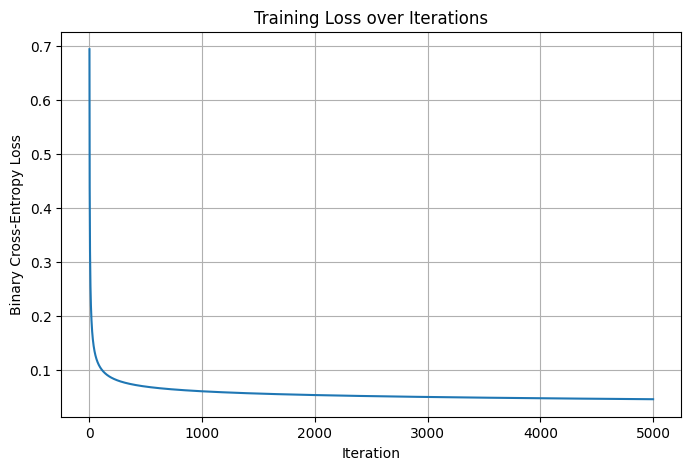

In [167]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), loss_history)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss over Iterations")

plt.grid(True)
plt.show()

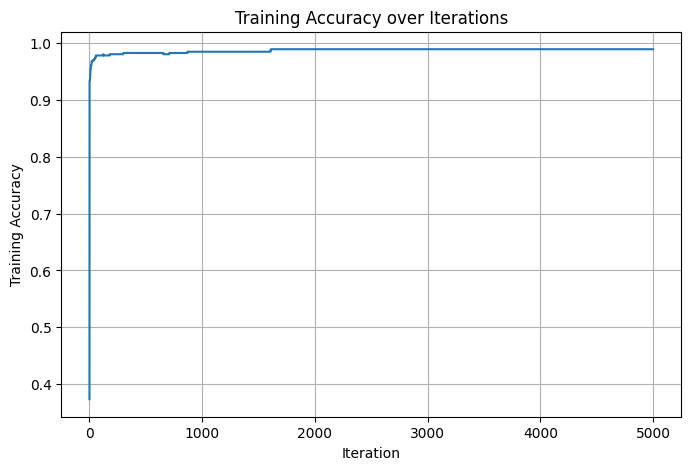

In [168]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), accuracy_history)

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy over Iterations")

plt.grid(True)
plt.show()

In [169]:
learning_rates = [0.001, 0.01, 0.1, 0.15]

results = {}

for learning_rate in learning_rates:

    theta = np.zeros(X_train_scaled.shape[1])
    loss_history = []
    accuracy_history = []

    for i in range(Iterations):

        z = X_train_scaled.dot(theta)
        p = sigmoid(z)

        loss_value = loss(len(y_train), p, y_train)
        loss_history.append(loss_value)

        y_pred = (p >= 0.5).astype(int)
        accuracy = np.mean(y_pred == y_train)
        accuracy_history.append(accuracy)

        gradient_value = gradient(
            X_train_scaled,
            y_train,
            p
        )

        theta = theta - learning_rate * gradient_value

    results[learning_rate] = {
        "theta": theta.copy(),
        "loss_history": loss_history.copy(),
        "accuracy_history": accuracy_history.copy()
    }

**2.7 Loss + Accuracy histories**

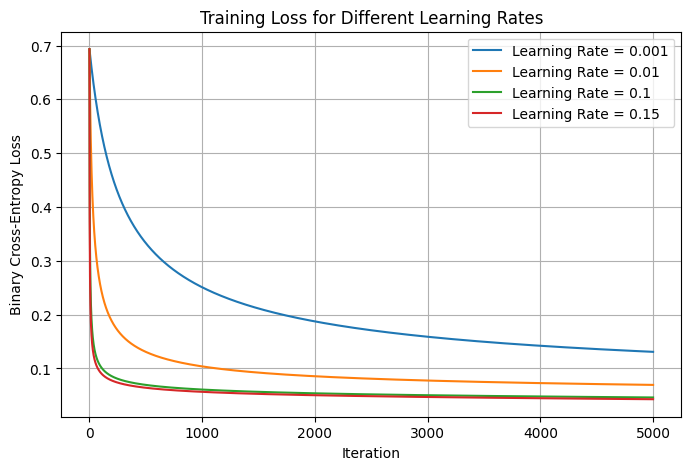

In [170]:
plt.figure(figsize=(8, 5))

for learning_rate in learning_rates:
    plt.plot(
        range(Iterations),
        results[learning_rate]["loss_history"],
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

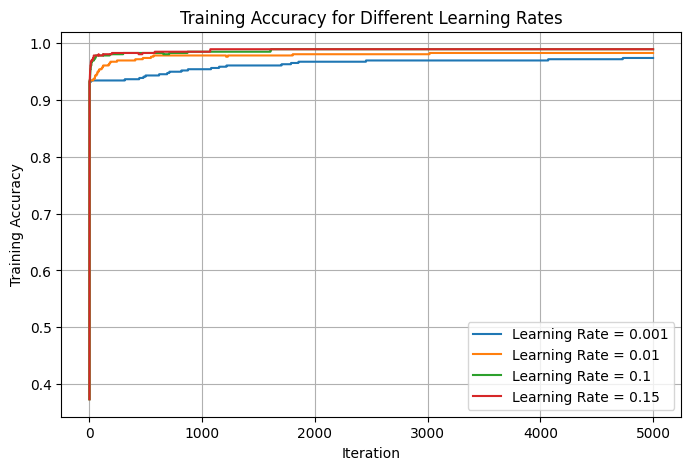

In [171]:
plt.figure(figsize=(8, 5))

for learning_rate in learning_rates:
    plt.plot(
        range(Iterations),
        results[learning_rate]["accuracy_history"],
        label=f"Learning Rate = {learning_rate}"
    )

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy for Different Learning Rates")
plt.legend()
plt.grid(True)

plt.show()

In [172]:
for learning_rate in learning_rates:
    final_loss = results[learning_rate]["loss_history"][-1]
    final_accuracy = results[learning_rate]["accuracy_history"][-1]

    print(f"Learning Rate: {learning_rate}")
    print(f"Final Loss: {final_loss:.4f}")
    print(f"Final Accuracy: {final_accuracy:.4f}")
    print()

Learning Rate: 0.001
Final Loss: 0.1309
Final Accuracy: 0.9736

Learning Rate: 0.01
Final Loss: 0.0695
Final Accuracy: 0.9824

Learning Rate: 0.1
Final Loss: 0.0462
Final Accuracy: 0.9890

Learning Rate: 0.15
Final Loss: 0.0429
Final Accuracy: 0.9890



In [173]:
theta=np.zeros(X_train_scaled.shape[1])
Iterations=5000
learning_rate=0.1
loss_history = []
accuracy_history = []

for i in range(Iterations):
    z = X_train_scaled.dot(theta)
    p = sigmoid(z)

    loss_value = loss(len(y_train), p, y_train)
    loss_history.append(loss_value)

    y_pred = (p >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_train)
    accuracy_history.append(accuracy)

    gradient_value = gradient(X_train_scaled, y_train, p)
    theta = theta - learning_rate * gradient_value


print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print("Initial accuracy:", accuracy_history[0])
print("Final accuracy:", accuracy_history[-1])

Initial loss: 0.6931471805599453
Final loss: 0.046169779211962025
Initial accuracy: 0.37362637362637363
Final accuracy: 0.989010989010989


In [174]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate linear scores for test data
z_test = X_test_scaled.dot(theta)

# Convert scores to probabilities
p_test = sigmoid(z_test)

# Convert probabilities to class predictions using threshold 0.5
y_pred_test = (p_test >= 0.5).astype(int)

# Calculate evaluation metrics
test_accuracy = accuracy_score(y_test, y_pred_test)
test_precision = precision_score(y_test, y_pred_test)
test_recall = recall_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test)

# Print results
print("Test Accuracy:", test_accuracy)
print("Test Precision:", test_precision)
print("Test Recall:", test_recall)
print("Test F1 Score:", test_f1)

Test Accuracy: 0.9736842105263158
Test Precision: 0.975609756097561
Test Recall: 0.9523809523809523
Test F1 Score: 0.963855421686747


0.6931471805599453
0.37362637362637363
5000
5000
Initial loss: 0.6931471805599453
Final loss: 0.046169779211962025
Initial accuracy: 0.37362637362637363
Final accuracy: 0.989010989010989


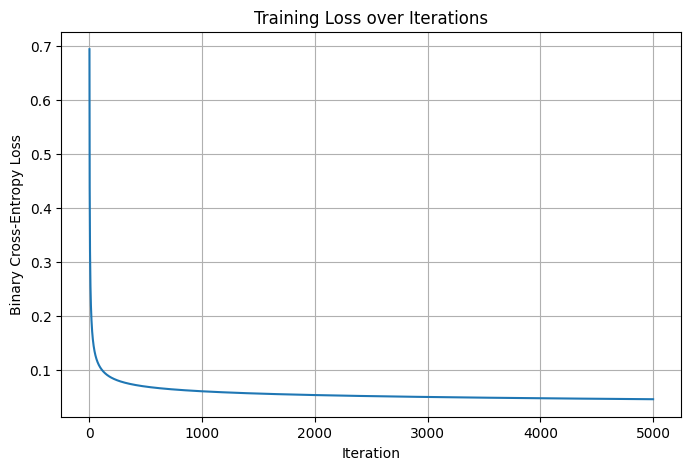

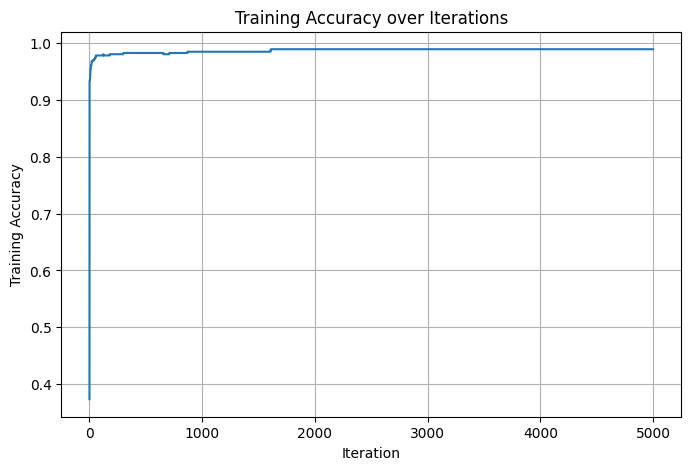

In [175]:
theta=np.zeros(X_train_scaled.shape[1])
Iterations=5000
learning_rate=0.1
loss_history = []
accuracy_history = []

for i in range(Iterations):
    z = X_train_scaled.dot(theta)
    p = sigmoid(z)

    loss_value = loss(len(y_train), p, y_train)
    loss_history.append(loss_value)

    y_pred = (p >= 0.5).astype(int)
    accuracy = np.mean(y_pred == y_train)
    accuracy_history.append(accuracy)

    gradient_value = gradient(X_train_scaled, y_train, p)
    theta = theta - learning_rate * gradient_value

print(loss_history[0])
print(accuracy_history[0])
print(len(loss_history))
print(len(accuracy_history))
print("Initial loss:", loss_history[0])
print("Final loss:", loss_history[-1])

print("Initial accuracy:", accuracy_history[0])
print("Final accuracy:", accuracy_history[-1])

plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), loss_history)

plt.xlabel("Iteration")
plt.ylabel("Binary Cross-Entropy Loss")
plt.title("Training Loss over Iterations")

plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), accuracy_history)

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy over Iterations")

plt.grid(True)
plt.show()

Confusion Matrix:
[[71  1]
 [ 2 40]]


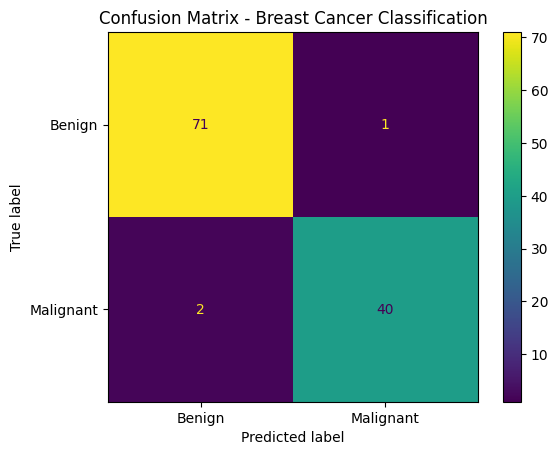

In [176]:
# Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Calculate confusion matrix
cm = confusion_matrix(y_test, y_pred_test)

print("Confusion Matrix:")
print(cm)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix - Breast Cancer Classification")
plt.show()

# Problem 2 b)

In [177]:
#change in loss to avoid log(0)=-infinity
def loss_regularized(m, p, y, theta, lambda_value):
    epsilon = 1e-15
    p = np.clip(p, epsilon, 1 - epsilon)

    loss_value = (-1/m) * ((np.dot(y.T, np.log(p))+ np.dot((1-y).T, np.log(1-p))))+lambda_value/(2*m)*np.sum(theta[1:]**2)

    return loss_value

def gradient_regularized(X, y, p, theta, lambda_value):
    m = X.shape[0]

    # Normal logistic regression gradient
    gradient_value = (1/m) * np.dot(X.T, (p - y))

    # Add L2 penalty only to weights, not to bias theta[0]
    gradient_value[1:] += (lambda_value / m) * theta[1:]

    return gradient_value

In [178]:
lambda_value = 1.0
theta_reg = np.zeros(X_train_scaled.shape[1])

loss_history_reg = []
accuracy_history_reg = []

In [179]:
for i in range(Iterations):

    z = X_train_scaled.dot(theta_reg)
    p = sigmoid(z)

    # regularized loss
    loss_value_reg = loss_regularized(
        len(y_train),
        p,
        y_train,
        theta_reg,
        lambda_value
    )
    loss_history_reg.append(loss_value_reg)

    # accuracy
    y_pred_reg = (p >= 0.5).astype(int)
    accuracy_reg = np.mean(y_pred_reg == y_train)
    accuracy_history_reg.append(accuracy_reg)

    # regularized gradient
    gradient_value_reg = gradient_regularized(
        X_train_scaled,
        y_train,
        p,
        theta_reg,
        lambda_value
    )

    # theta update
    theta_reg = theta_reg - learning_rate * gradient_value_reg

In [180]:
print("Initial regularized loss:", loss_history_reg[0])
print("Final regularized loss:", loss_history_reg[-1])
print("Initial accuracy:", accuracy_history_reg[0])
print("Final accuracy:", accuracy_history_reg[-1])

Initial regularized loss: 0.6931471805599453
Final regularized loss: 0.06881530280486592
Initial accuracy: 0.37362637362637363
Final accuracy: 0.989010989010989


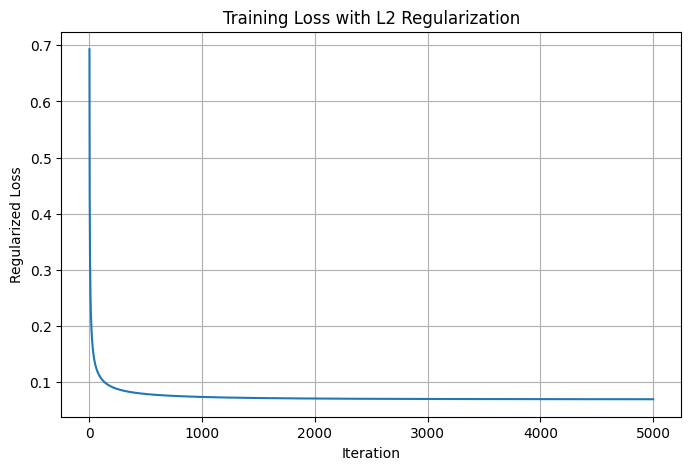

In [181]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), loss_history_reg)

plt.xlabel("Iteration")
plt.ylabel("Regularized Loss")
plt.title("Training Loss with L2 Regularization")
plt.grid(True)

plt.show()

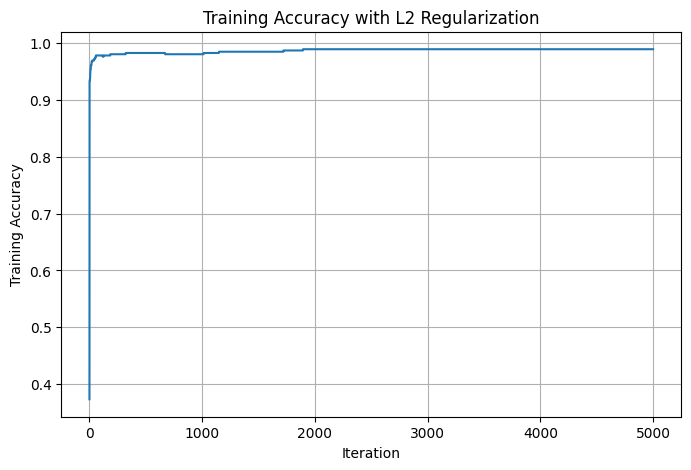

In [182]:
plt.figure(figsize=(8, 5))

plt.plot(range(Iterations), accuracy_history_reg)

plt.xlabel("Iteration")
plt.ylabel("Training Accuracy")
plt.title("Training Accuracy with L2 Regularization")
plt.grid(True)

plt.show()

In [183]:
# Evaluate regularized model on test data

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Linear scores
z_test_reg = X_test_scaled.dot(theta_reg)

# Probabilities
p_test_reg = sigmoid(z_test_reg)

# Class predictions
y_pred_test_reg = (p_test_reg >= 0.5).astype(int)

# Evaluation metrics
test_accuracy_reg = accuracy_score(y_test, y_pred_test_reg)
test_precision_reg = precision_score(y_test, y_pred_test_reg)
test_recall_reg = recall_score(y_test, y_pred_test_reg)
test_f1_reg = f1_score(y_test, y_pred_test_reg)

print("Regularized Model Test Results")
print("--------------------------------")
print("Test Accuracy:", test_accuracy_reg)
print("Test Precision:", test_precision_reg)
print("Test Recall:", test_recall_reg)
print("Test F1 Score:", test_f1_reg)

Regularized Model Test Results
--------------------------------
Test Accuracy: 0.9736842105263158
Test Precision: 1.0
Test Recall: 0.9285714285714286
Test F1 Score: 0.9629629629629629


Confusion Matrix:
[[72  0]
 [ 3 39]]


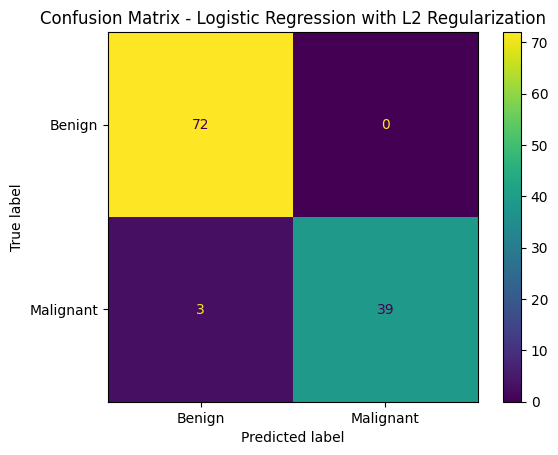

In [184]:
# Confusion Matrix - Regularized Model

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm_reg = confusion_matrix(y_test, y_pred_test_reg)

print("Confusion Matrix:")
print(cm_reg)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_reg,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Confusion Matrix - Logistic Regression with L2 Regularization")
plt.show()

In [185]:
# Compare models with and without regularization

comparison = pd.DataFrame({
    "Model": [
        "Without Regularization",
        "With L2 Regularization"
    ],
    "Accuracy": [
        test_accuracy,
        test_accuracy_reg
    ],
    "Precision": [
        test_precision,
        test_precision_reg
    ],
    "Recall": [
        test_recall,
        test_recall_reg
    ],
    "F1 Score": [
        test_f1,
        test_f1_reg
    ]
})

display(comparison)

,Model,Accuracy,Precision,Recall,F1 Score
0,Without Regularization,0.973684,0.97561,0.952381,0.963855
1,With L2 Regularization,0.973684,1.00000,0.928571,0.962963


In [186]:
# Compare magnitude of model weights

weight_norm_no_reg = np.linalg.norm(theta[1:])
weight_norm_reg = np.linalg.norm(theta_reg[1:])

print("Weight norm without regularization:", weight_norm_no_reg)
print("Weight norm with regularization:", weight_norm_reg)

Weight norm without regularization: 5.0457508743397375
Weight norm with regularization: 3.6113487118925485
